In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)


In [ ]:
def get_sheet(filename, sheetname=None):
    if sheetname is not None:
        df = pd.read_excel(filename, sheet_name=sheetname)
    else:
        try:
            df = pd.read_csv(filename, sep=',', decimal=',', quotechar='"', engine='python')
        except:
            df = pd.read_excel(filename)

    if "Portfolio Macro Data.xlsx" in filename:
        df.columns = ['Date'] + df.columns[1:].tolist()

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
    df = df.sort_index()
    df = df.astype(float)
    return df


In [ ]:
# I put the ETF files into a "dataset" folder which itself is at the same level as the notebook

asset_info = pd.read_csv("datasets/Meta.csv")
asset_info.columns = ["ISIN", "Ticker", "ETF & Funds", "Provider", "Object", "Sector", "Geography", "Total Expense Ratio", "Exchange", "Replication Method"]
asset_info = asset_info.replace({"No data": np.nan}).dropna(subset=["Ticker"]).set_index("Ticker")

df_close = get_sheet("datasets/ClosePrice.csv")
df_open = get_sheet("datasets/OpenPrice.csv")
df_vol = get_sheet("datasets/Volume.csv")


C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting

Initial data coverage

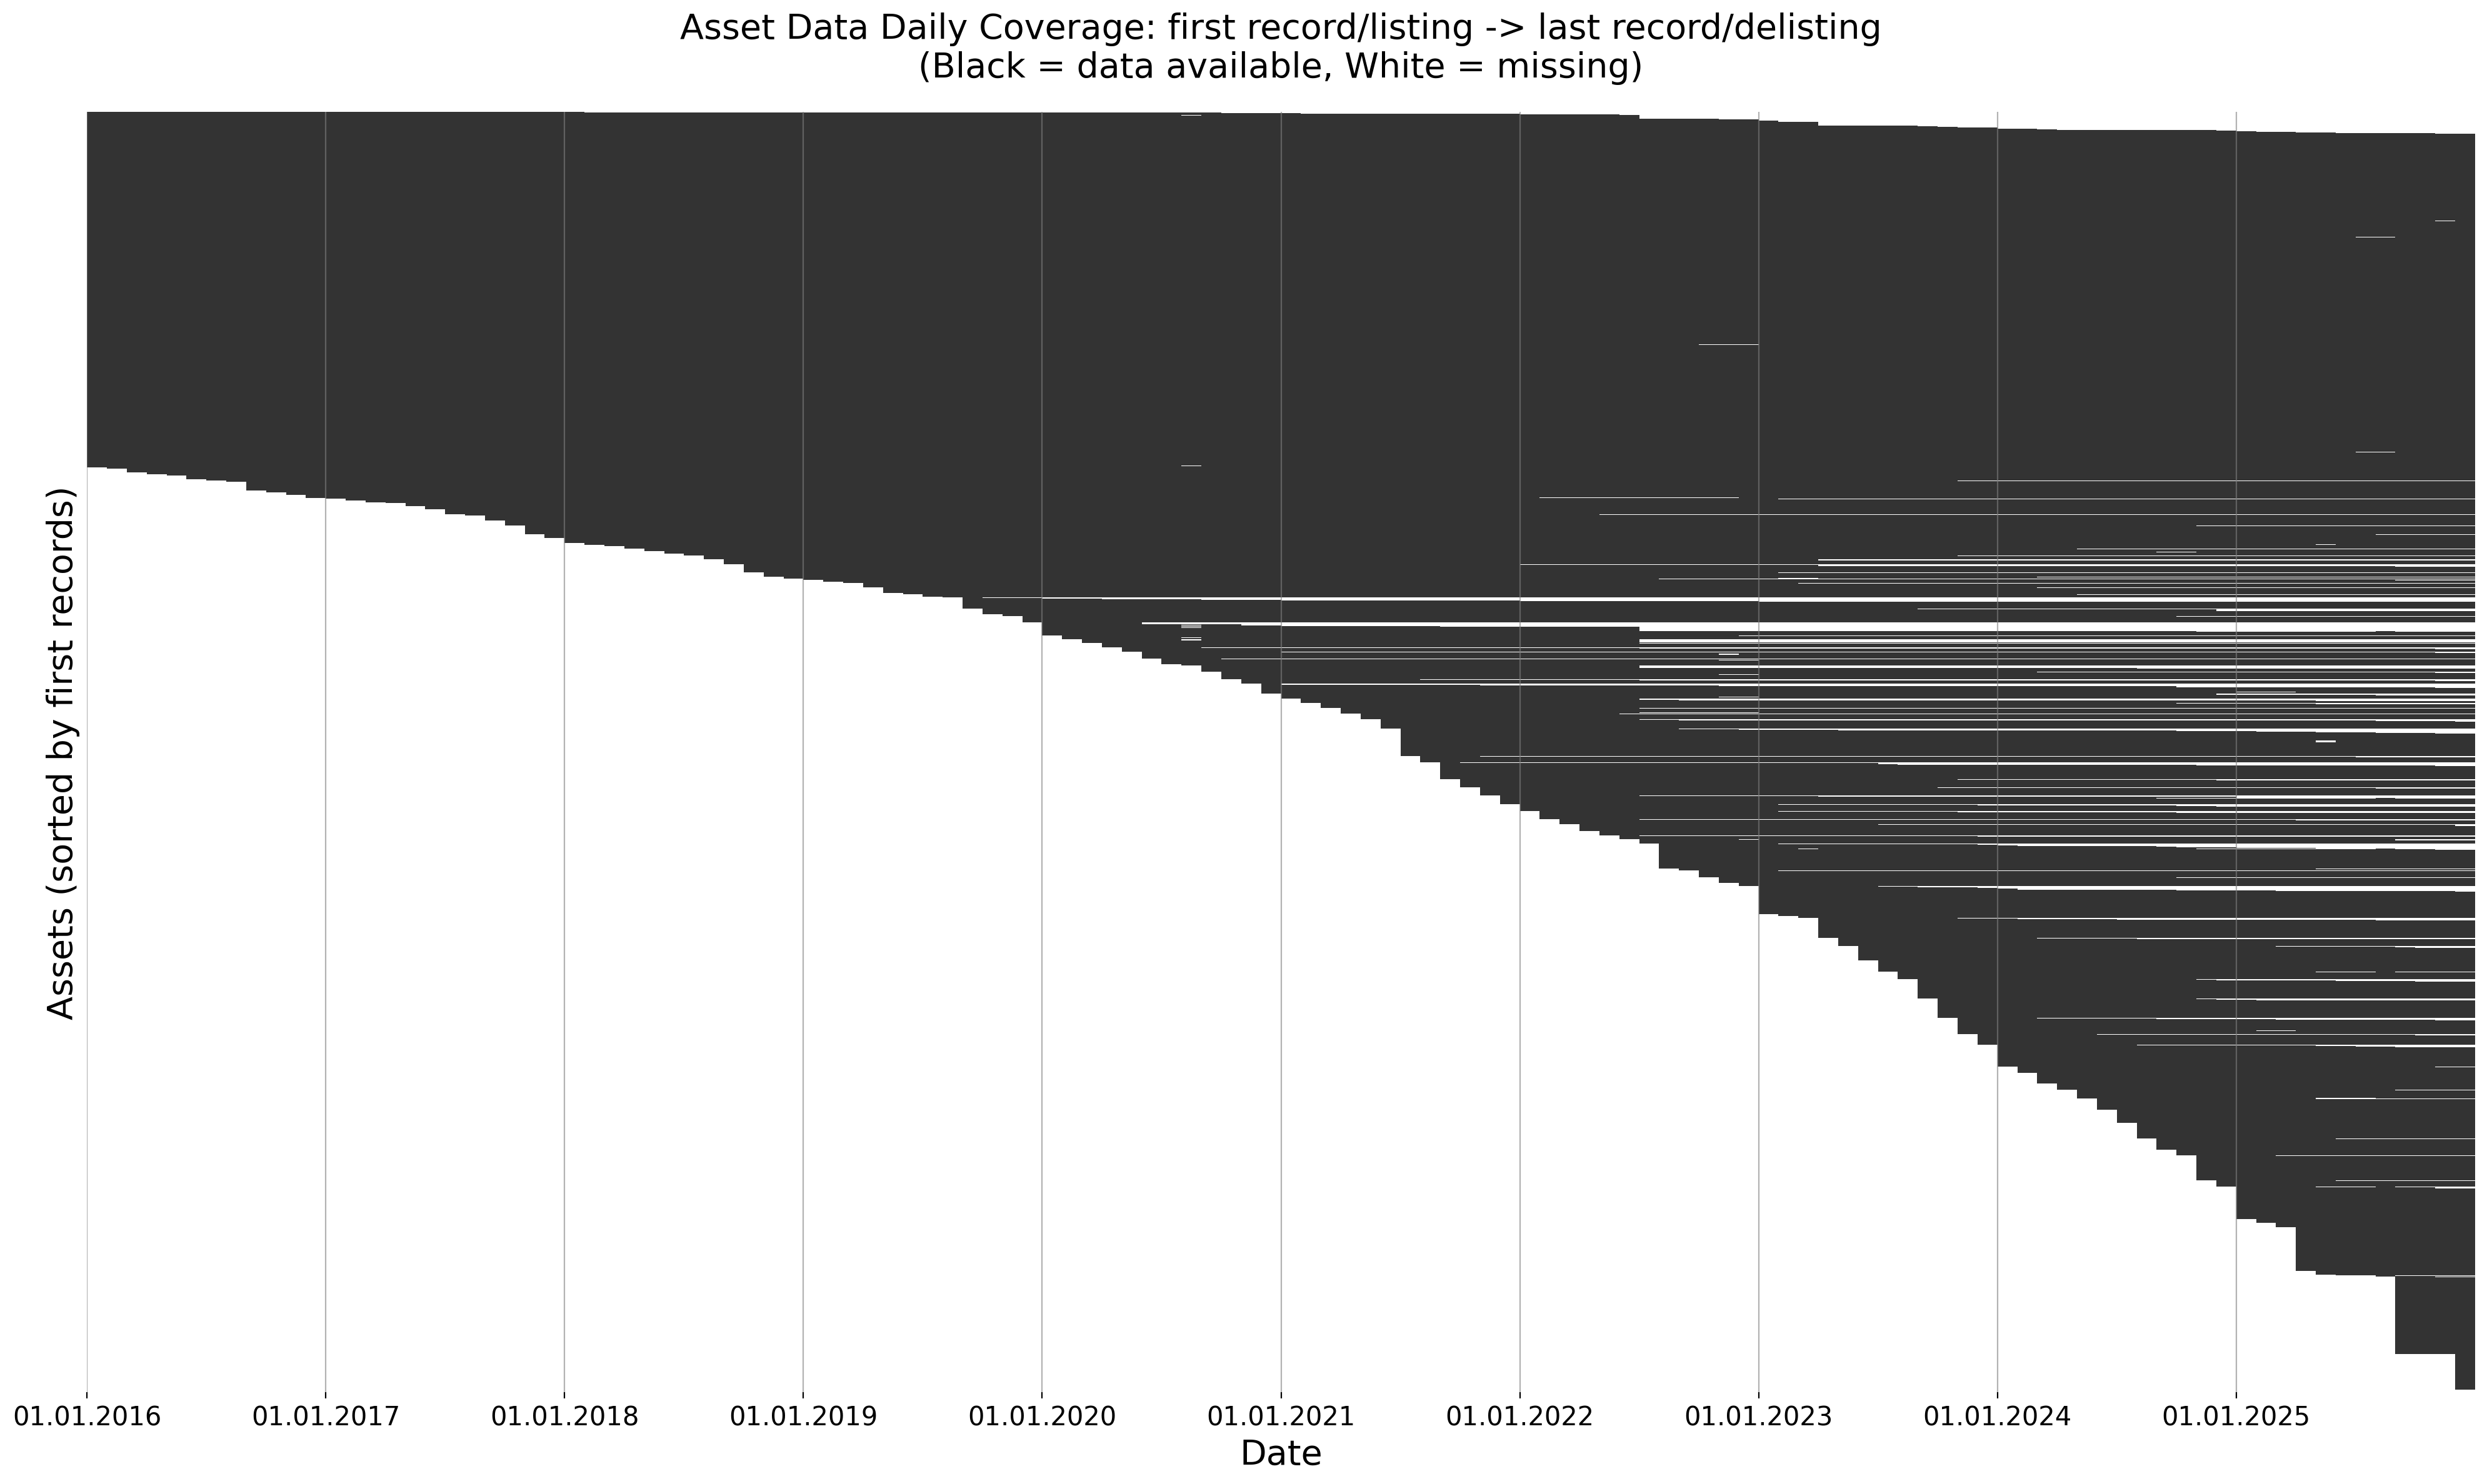

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

coverage = df_close.resample('ME').max().notna().astype(int)

def plot_coverage(coverage):
    # Sorting (just for clear visuals)
    first_dates = {}
    last_dates = {}
    for asset in coverage.columns:
        if coverage[asset].size > 0:
            non_zero = coverage[coverage[asset] == 1]
            if not non_zero.empty:
                first_date = non_zero.index[0]
                last_date = non_zero.index[-1]
            else:
                first_date = pd.Timestamp('2050-12-31')
                last_date = pd.Timestamp('1970-01-01')
        else:
            first_date = pd.Timestamp('2050-12-31')
            last_date = pd.Timestamp('1970-01-01')
        
        first_dates[asset] = first_date
        last_dates[asset] = last_date

    sorted_assets = sorted(first_dates.keys(), 
                        key=lambda x: (first_dates[x], last_dates[x]))
    coverage = coverage[sorted_assets]

    # Graph
    fig, ax = plt.subplots(figsize=(20, 12))
    cmap = ListedColormap(['white', 'black'])

    sns.heatmap(coverage.T, 
                ax=ax, 
                cmap=cmap, 
                cbar=False,
                linecolor='gray', 
                alpha=0.8)

    ax.set_xlabel('Date', fontsize=20)
    ax.set_ylabel(f'Assets (sorted by first records)', fontsize=20)
    ax.set_title('Asset Data Daily Coverage: first record/listing -> last record/delisting\n(Black = data available, White = missing)', 
                fontsize=20, fontweight='regular', pad=20)

    first_days = coverage.index
    n_cols = len(first_days)
    tick_positions = np.arange(0, n_cols, 12)  # Labels every 12 months
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([first_days[int(i)].strftime('01.%m.%Y') for i in tick_positions], 
                    rotation=0, ha='center')
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=15)
    for i in tick_positions:
        ax.axvline(x=i, color='gray', linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_coverage(coverage)


In [ ]:
check1 = (df_vol.columns.tolist() == df_close.columns.tolist() == df_open.columns.tolist())
check2 = (df_vol.index.tolist() == df_close.index.tolist() == df_open.index.tolist())

print(f"Checking if the order and quantity of indices and columns match:")
print(f"Column integrity: {check1}")
print(f"Index integrity: {check2}")


Checking if the order and quantity of indices and columns match:
Column integrity: True
Index integrity: True


Calculating daily trading amount in $ (using open-close mean price)

In [ ]:
df_amo = (df_close + df_open) / 2 * df_vol
df_amo_monthly = df_amo.resample('ME').sum()


In [ ]:
min_months = 36 # 36 month with at least 1 trading day in each
df_eligibility = df_amo_monthly.rolling(min_months+1, min_periods=min_months+1).sum().gt(min_months).astype(int)


Filtering option 1: a fixed threshold (possibly with a rolling mean estimation)

In [ ]:
df_amo_monthly_eligible = (df_amo_monthly * df_eligibility).replace({0: np.nan})
amount_list = pd.Series(df_amo_monthly.values.flatten()).dropna().replace({0: np.nan})


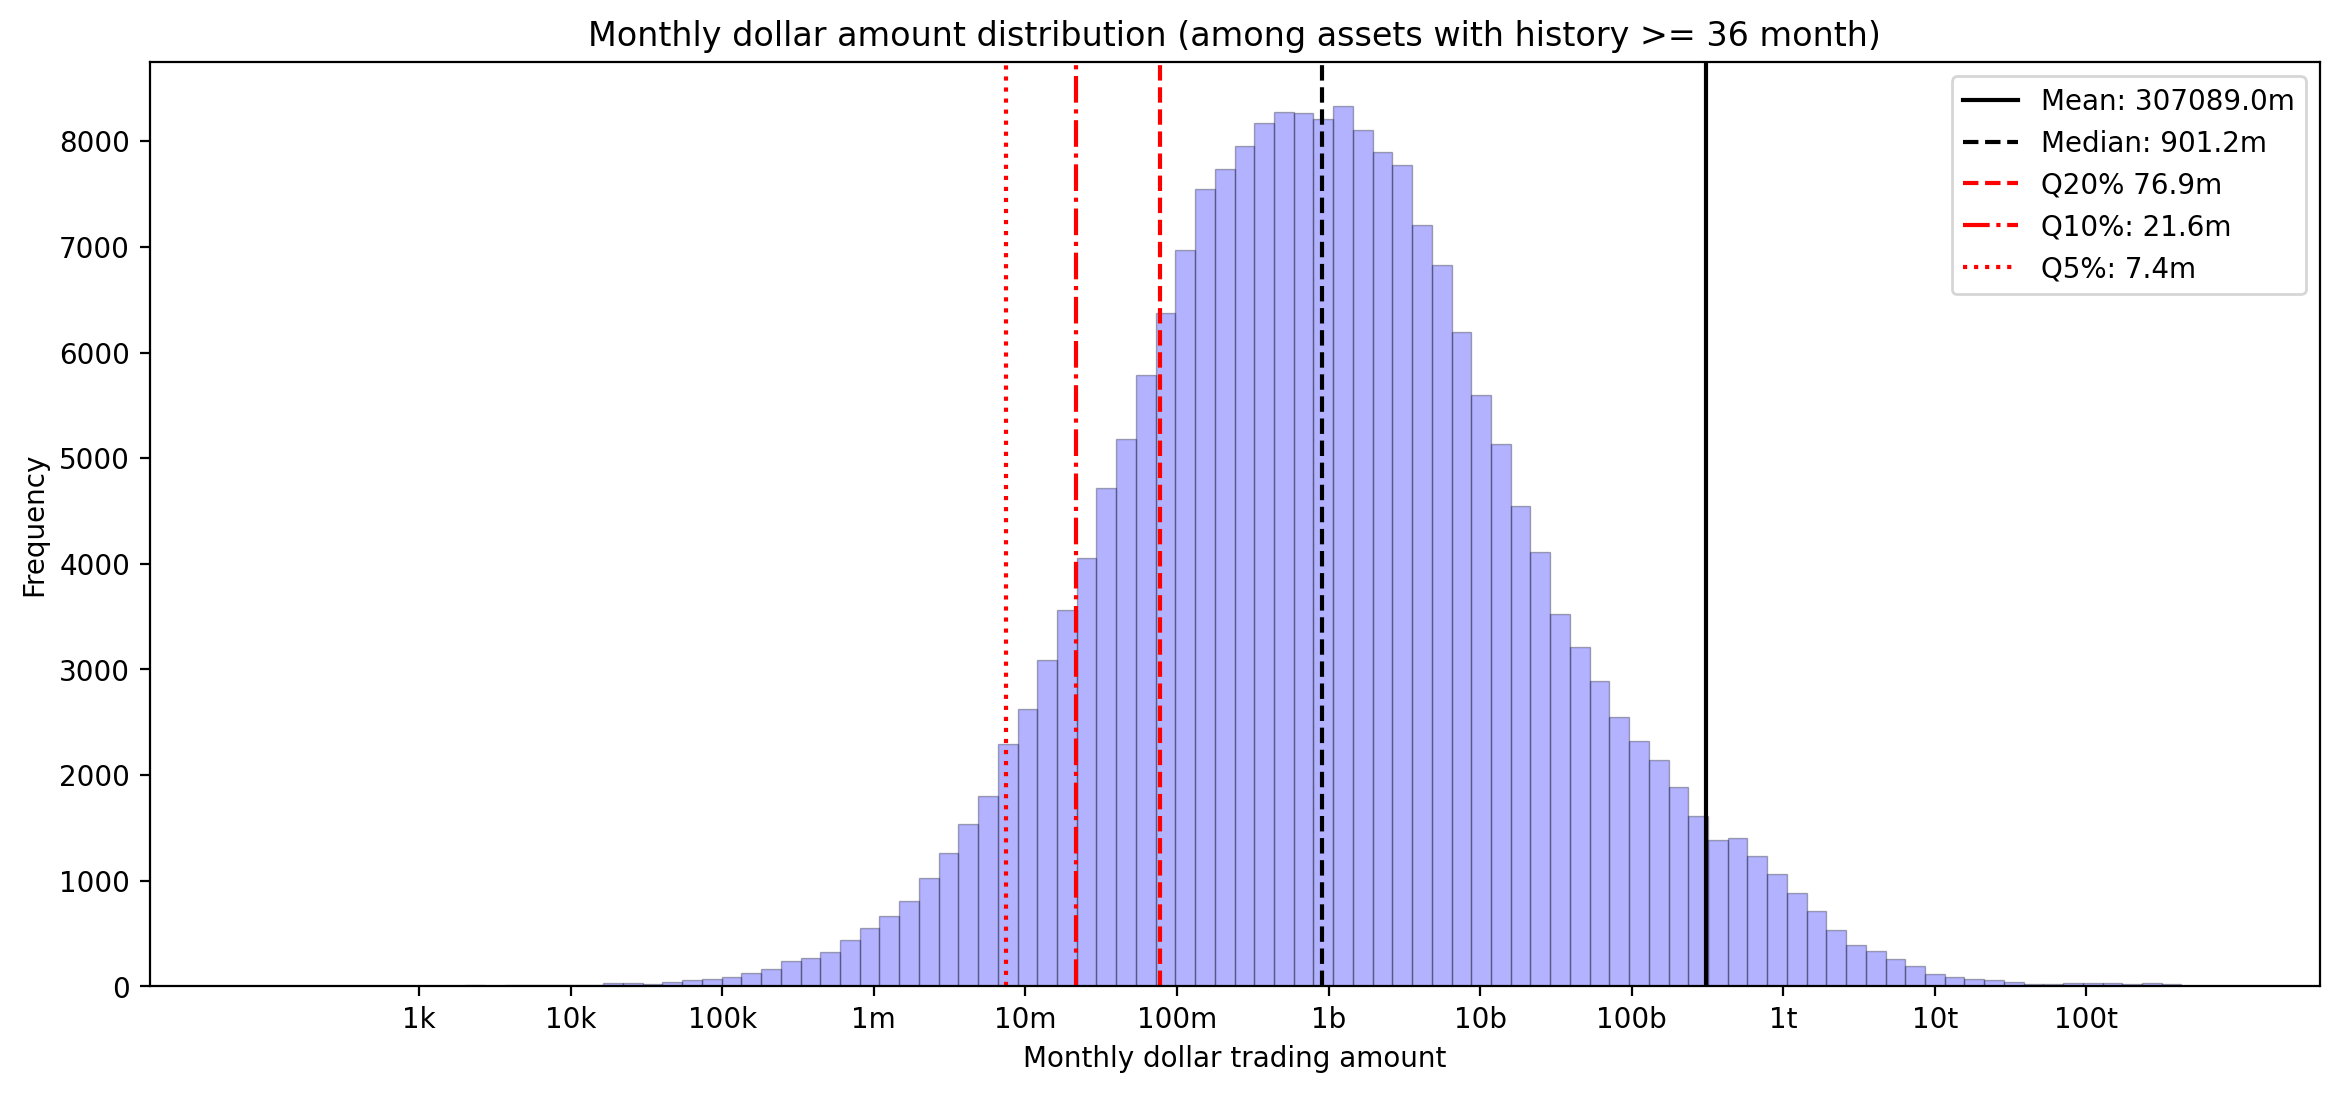

In [ ]:
data = amount_list

median = np.median(data.dropna())
mean = np.mean(data.dropna())
q05 = np.quantile(data.dropna(), 0.05)
q10 = np.quantile(data.dropna(), 0.1)
q20 = np.quantile(data.dropna(), 0.2)

ticks = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
fig, ax = plt.subplots(figsize=(14,6))
ax.hist(np.log10(data), bins=100, edgecolor='black', linewidth=0.5, color='blue', alpha=0.3)

ax.set_xticks(ticks)
ax.set_xticklabels(['1k', '10k', '100k', '1m', '10m', '100m', '1b', '10b', '100b', '1t', '10t', '100t'])

ax.axvline(np.log10(mean), color='black', linestyle='-', linewidth=1.5, 
        label=f'Mean: {mean/1e6:.1f}m')
ax.axvline(np.log10(median), color='black', linestyle='--', linewidth=1.5, 
        label=f'Median: {median/1e6:.1f}m')
ax.axvline(np.log10(q20), color='red', linestyle='--', linewidth=1.5, 
        label=f'Q20% {q20/1e6:.1f}m')
ax.axvline(np.log10(q10), color='red', linestyle='-.', linewidth=1.5, 
        label=f'Q10%: {q10/1e6:.1f}m')
ax.axvline(np.log10(q05), color='red', linestyle=':', linewidth=1.5, 
        label=f'Q5%: {q05/1e6:.1f}m')

ax.legend()
ax.set_ylabel('Frequency')
ax.set_xlabel('Monthly dollar trading amount')
ax.set_title(f"Monthly dollar amount distribution (among assets with history >= {min_months} month)")
plt.show()


Filtering option 2: a fixed % threshold (possibly with a rolling mean estimation)

In [ ]:
df_amo_monthly_relative = df_amo_monthly.div(df_amo_monthly.sum(axis=1), axis=0).replace({0: np.nan})

amount_list = pd.Series(df_amo_monthly_relative.values.flatten()).dropna()


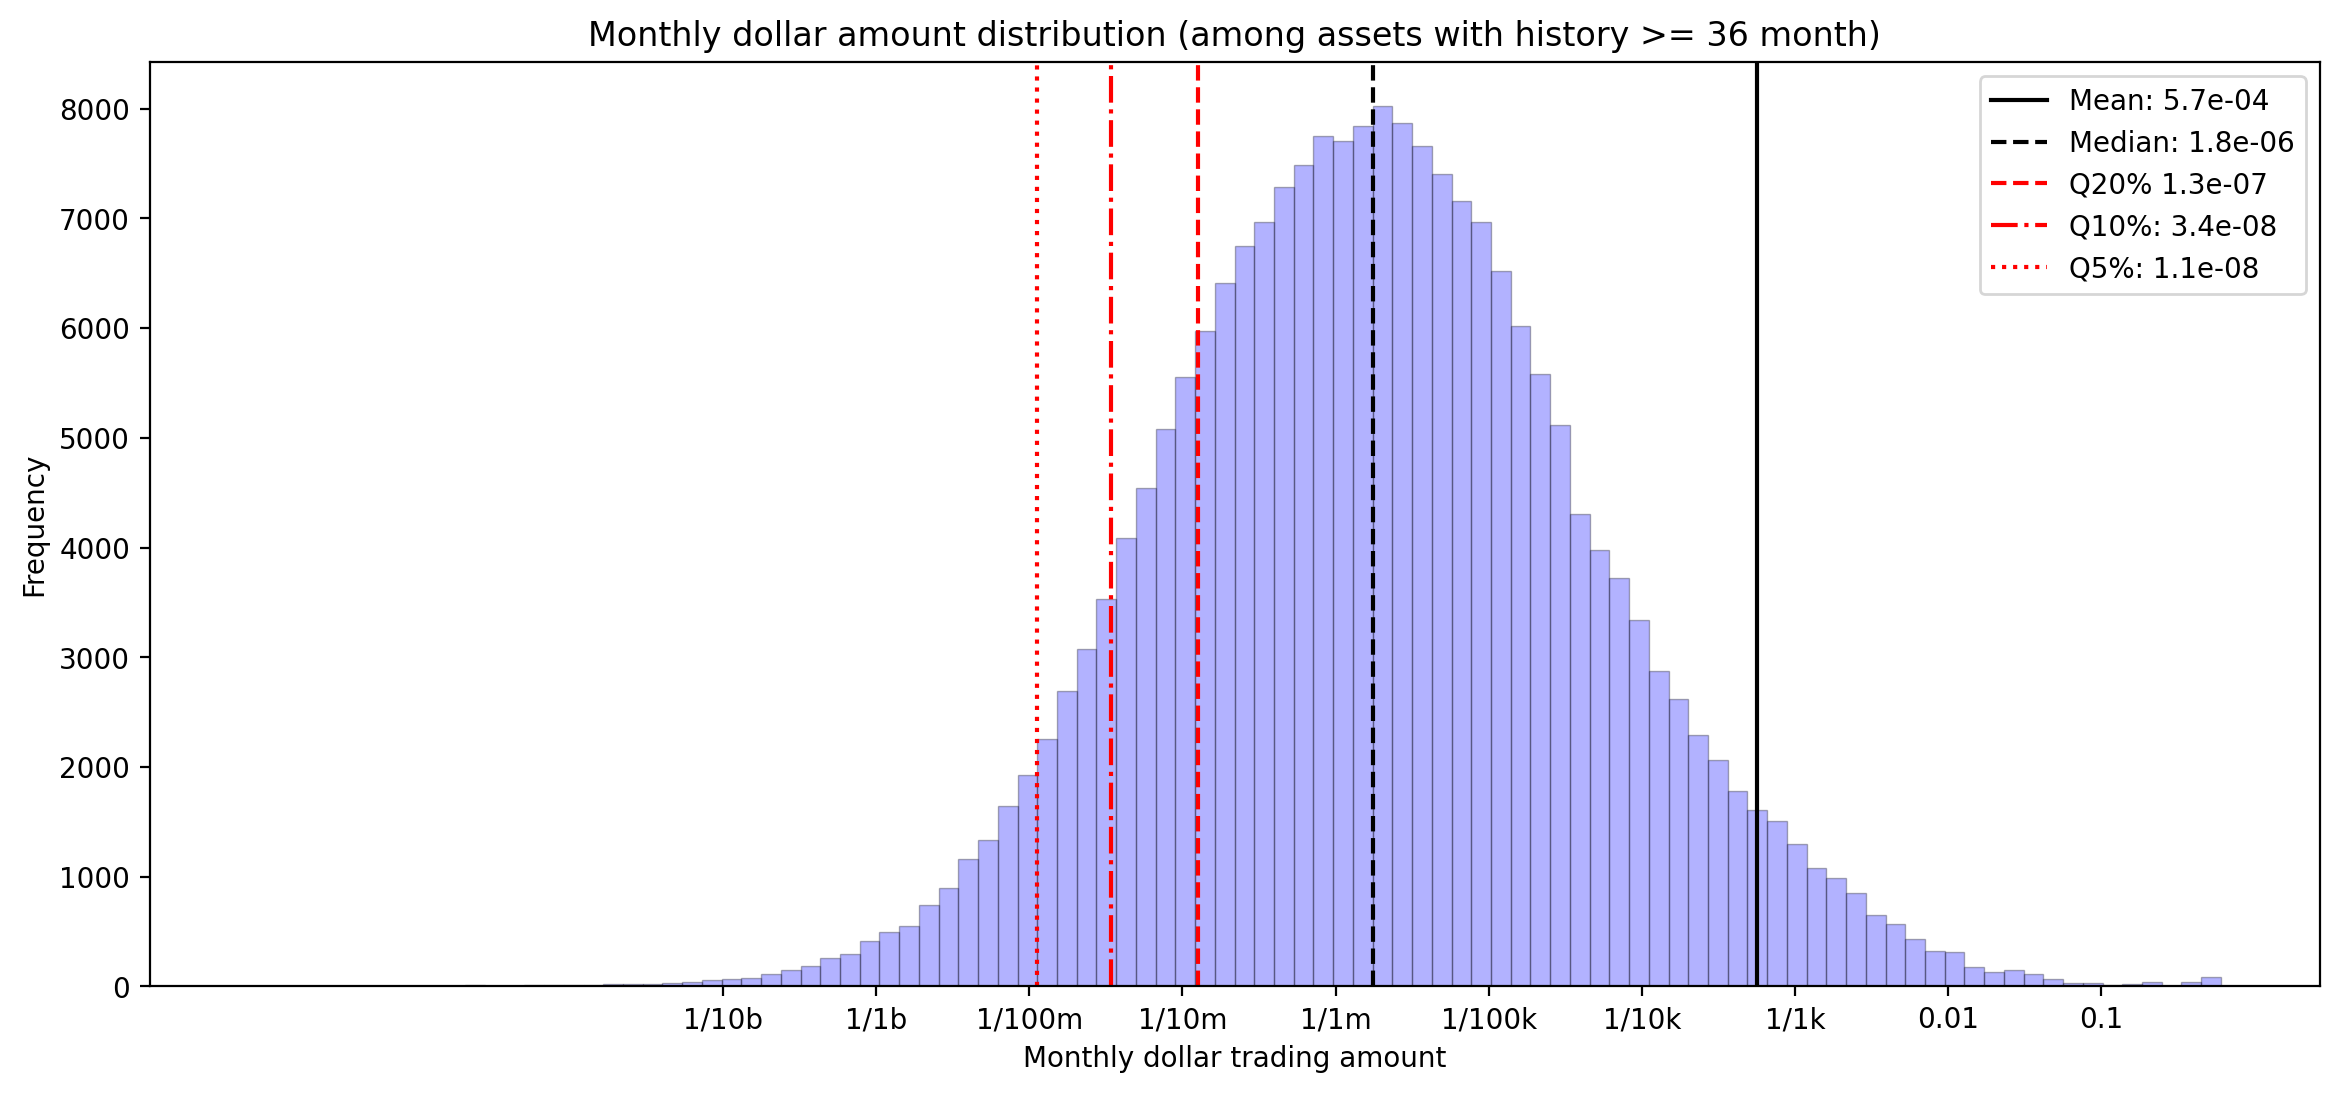

In [ ]:
data = amount_list

median = np.median(data.dropna())
mean = np.mean(data.dropna())
q05 = np.quantile(data.dropna(), 0.05)
q10 = np.quantile(data.dropna(), 0.1)
q20 = np.quantile(data.dropna(), 0.2)

ticks = [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1]
fig, ax = plt.subplots(figsize=(14,6))
ax.hist(np.log10(data), bins=100, edgecolor='black', linewidth=0.5, color='blue', alpha=0.3)

ax.set_xticks(ticks)
ax.set_xticklabels(['1/10b', '1/1b', '1/100m', '1/10m', '1/1m', '1/100k', '1/10k', '1/1k', 1/100, 1/10])

ax.axvline(np.log10(mean), color='black', linestyle='-', linewidth=1.5, 
        label=f'Mean: {mean:.1e}')
ax.axvline(np.log10(median), color='black', linestyle='--', linewidth=1.5, 
        label=f'Median: {median:.1e}')
ax.axvline(np.log10(q20), color='red', linestyle='--', linewidth=1.5, 
        label=f'Q20% {q20:.1e}')
ax.axvline(np.log10(q10), color='red', linestyle='-.', linewidth=1.5, 
        label=f'Q10%: {q10:.1e}')
ax.axvline(np.log10(q05), color='red', linestyle=':', linewidth=1.5, 
        label=f'Q5%: {q05:.1e}')

ax.legend()
ax.set_ylabel('Frequency')
ax.set_xlabel('Monthly dollar trading amount')
ax.set_title(f"Monthly dollar amount distribution (among assets with history >= {min_months} month)")
plt.show()


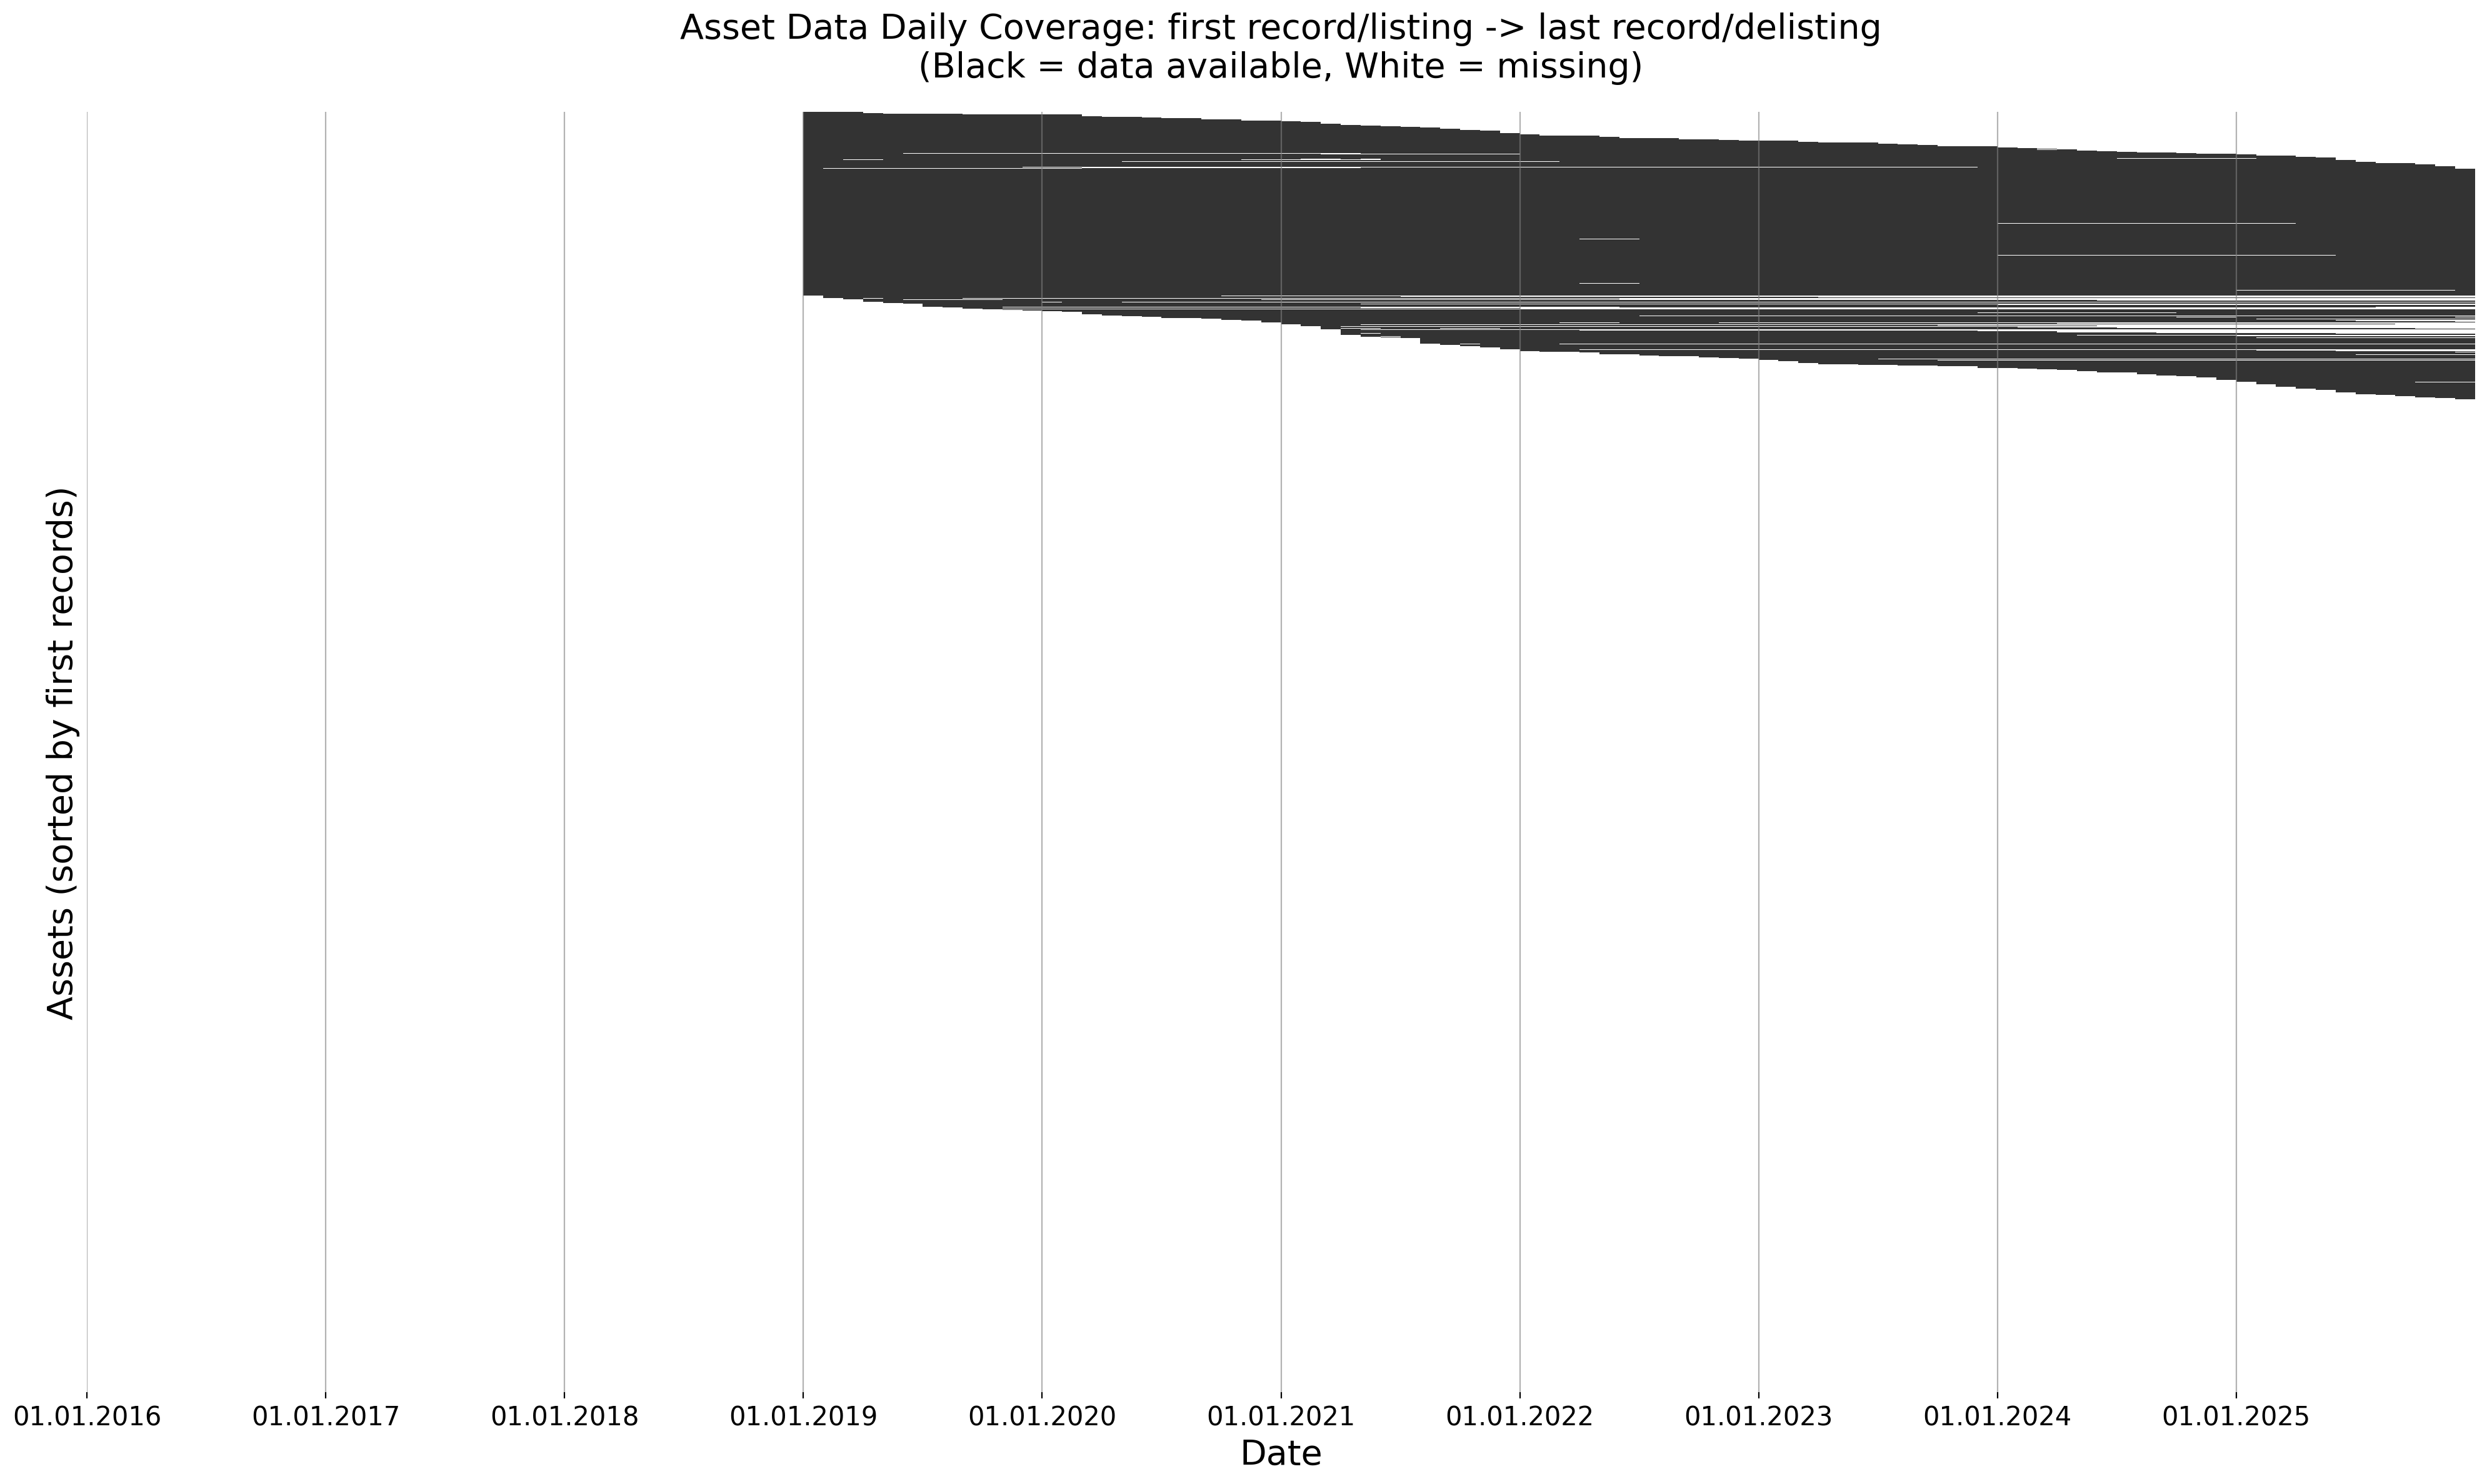

In [ ]:
amount_threshold = 1e10 # Let's pick $10 bil threshold
amount_threshold = 1e-5
rolling_window = 36 # Have to take some rolling mean window to smooth out, otherwise sample too unstable

# We could use the rolling window of the percentage (mean of divisions), but taking the percentage of rolling means makes more sense (division of means)
df_amo_rolling = df_amo_monthly.rolling(window=rolling_window).mean()
df_amo_rolling = df_amo_rolling.div(df_amo_rolling.sum(axis=1), axis=0)

eligibility_matrix = (df_amo_rolling.shift(1) > amount_threshold).astype(int) * df_eligibility

plot_coverage(eligibility_matrix)


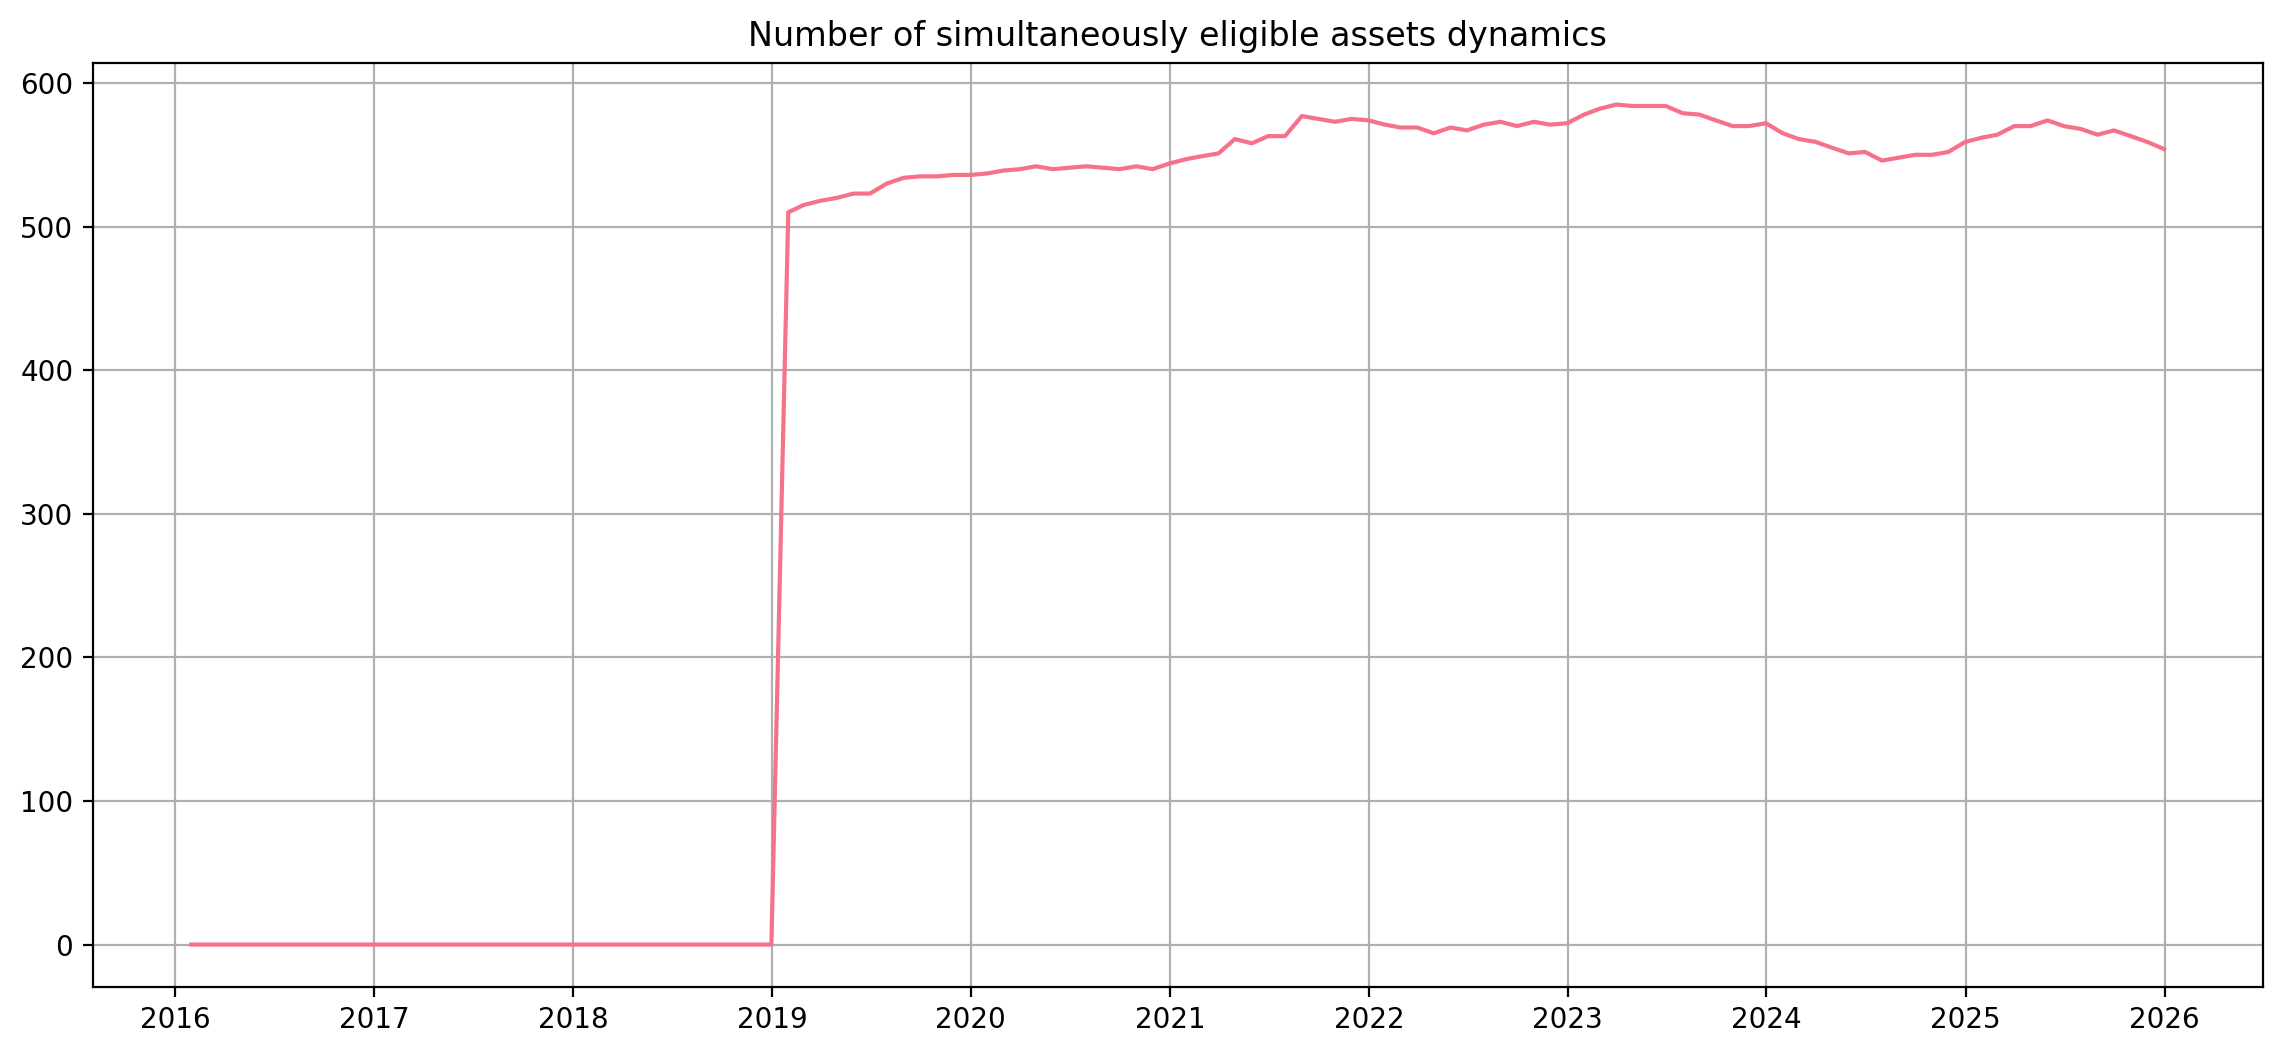

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eligibility_matrix.sum(axis=1))
ax.grid()
ax.set_title('Number of simultaneously eligible assets dynamics')
plt.show()

# A much more stable sample size, no matter the threshold!


In [ ]:
eligibility_matrix.to_csv('datasets/Eligibility.csv')
ticker_eligibility = eligibility_matrix.max(axis=0)
ticker_list = ticker_eligibility.loc[ticker_eligibility > 0].index.tolist()
with open('datasets/tickers.txt', 'w') as f: # also save a list of tickers that were eligible at any point of time
    for value in ticker_list:
        f.write(str(value) + '\n')


### Gathering the total sample (continuating of the code above)

In [ ]:
df_high = get_sheet("datasets/MaxPrice.csv")
df_low = get_sheet("datasets/MinPrice.csv")
df_aum = get_sheet("datasets/AUM.csv")


C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting

In [ ]:
macro_data1 = get_sheet("datasets/Portfolio Macro Data.xlsx", sheetname='4) Factor data')
macro_data2 = get_sheet("datasets/Portfolio Macro Data.xlsx", sheetname='5) Macro and rates predictors')
macro_data3 = get_sheet("datasets/Portfolio Macro Data.xlsx", sheetname='6) Regime and stress indicators')
macro_data4 = get_sheet("datasets/Portfolio Macro Data.xlsx", sheetname='7) Transaction costs and fees ')
macro_data5 = get_sheet("datasets/Portfolio Macro Data.xlsx", sheetname='8) Benchmarks')


C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"No data": np.nan, "Cbonds authorization is required": np.nan}).infer_objects(copy=False)
C:\Users\archie\AppData\Local\Temp\ipykernel_15288\684143407.py:15: FutureWarning: Downcasting

In [ ]:
macro_data_total = (macro_data1.merge(macro_data2, on='Date', how='outer')
                    .merge(macro_data3, on='Date', how='outer')
                    .merge(macro_data4, on='Date', how='outer')
                    .merge(macro_data5, on='Date', how='outer'))
macro_data_total


,Mkt-RF (market),SMB (size),HML (value),RMW (profitability),CMA (investment),MOM (momentum),RF,UST 1m YTM,UST 3m YTM,UST 2Y YTM,UST 5Y YTM,UST 10Y YTM,UST 30Y YTM,T10Y–3M,T10Y–2Y,SOFR O/N,SOFR 1m,SOFR 3m,SOFR 6m,SOFR 12m,EFFR O/N,"CPI inflation rate, monthly",5Y BEI,10Y BEI,IG OAS,HY OAS,NBER Recession,NY Fed Recession,VIX,"SEC Section 31 rate ($ per $1,000,000, sell-side)","FINRA TAF ($ per share, sell-side, capped)","FINRA TAF, max $ per trade/per ETF",S&P 500 TR,US Agg Bond Index TR
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-1.59,-0.77,0.52,0.35,0.42,-1.93,0.0,0.17,0.22,1.02,1.73,2.24,2.98,2.02,1.22,0.36,NaN,NaN,NaN,NaN,0.36,1.4,1.31,1.55,1.73,7.10,0.0,4.418262,20.70,18.4,0.000119,5.95,3763.990000,NaN
2016-01-05,0.13,-0.22,0.00,0.08,0.28,0.66,0.0,0.20,0.20,1.04,1.73,2.25,3.01,2.05,1.21,0.35,NaN,NaN,NaN,NaN,0.36,1.4,1.31,1.56,1.73,7.03,0.0,4.418262,19.34,18.4,0.000119,5.95,3771.570000,NaN
2016-01-06,-1.34,-0.23,0.01,0.13,0.02,1.87,0.0,0.21,0.21,0.99,1.65,2.18,2.94,1.97,1.19,0.38,NaN,NaN,NaN,NaN,0.36,1.4,1.26,1.53,1.74,7.11,0.0,4.418262,20.59,18.4,0.000119,5.95,3723.440000,NaN
2016-01-07,-2.44,-0.28,0.08,0.50,0.39,0.84,0.0,0.20,0.20,0.96,1.61,2.16,2.92,1.96,1.20,0.36,NaN,NaN,NaN,NaN,0.36,1.4,1.25,1.50,1.75,7.24,0.0,4.418262,24.99,18.4,0.000119,5.95,3635.290000,NaN
2016-01-08,-1.11,-0.52,-0.03,0.24,0.06,-0.09,0.0,0.20,0.20,0.94,1.57,2.13,2.91,1.93,1.19,0.36,NaN,NaN,NaN,NaN,0.36,1.4,1.23,1.48,1.77,7.23,0.0,4.418262,27.01,18.4,0.000119,5.95,3595.910000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.72,3.67,3.51,3.72,4.15,4.79,0.48,0.64,3.64,3.67738,3.67113,3.62770,3.49381,3.64,NaN,2.36,2.29,0.77,2.76,0.0,23.175364,16.75,0.0,0.000195,9.79,15408.150000,2356.94
2026-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.75,3.68,3.56,3.77,4.17,4.79,0.49,0.61,3.66,3.67536,3.66763,3.62032,3.48108,3.64,NaN,2.36,2.29,0.76,2.71,0.0,23.175364,15.84,0.0,0.000195,9.79,15448.300000,2354.47
2026-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.75,3.67,3.59,3.82,4.24,4.83,0.57,0.65,NaN,3.67328,3.66969,3.63020,3.50544,NaN,NaN,2.39,2.33,NaN,NaN,0.0,23.175364,15.86,0.0,0.000195,9.79,15439.473128,2349.05


Run ADF test to check stationarity of the macro factors

In [ ]:
from statsmodels.tsa.stattools import adfuller
results1 = {}
for col in macro_data_total.columns:
    try:
        initial_series = macro_data_total[col]

        pval1 = adfuller(initial_series.dropna())[1]
        result1 = '✅ YES' if pval1 < 0.05 else '❌ NO'
        results1[col] = result1
    except:
        results1[col] = '❌ ERROR'

print('Stationarity ADF unit root test:')
print(pd.Series(results1))


Stationarity ADF unit root test:
Mkt-RF (market)                                      ✅ YES
SMB (size)                                           ✅ YES
HML (value)                                          ✅ YES
RMW (profitability)                                  ✅ YES
CMA (investment)                                     ✅ YES
MOM (momentum)                                       ✅ YES
RF                                                    ❌ NO
UST 1m YTM                                            ❌ NO
UST 3m YTM                                            ❌ NO
UST 2Y YTM                                            ❌ NO
UST 5Y YTM                                            ❌ NO
UST 10Y YTM                                           ❌ NO
UST 30Y YTM                                           ❌ NO
T10Y–3M                                               ❌ NO
T10Y–2Y                                               ❌ NO
SOFR O/N                                              ❌ NO
SOFR 1m                

In [ ]:
# We see that RF, CPI, SEC rate and NY Fed Recession are discrete and not really fit for differentiation, so we'll skip them
exclude_cols = ['NY Fed Recession', 'RF', 'CPI inflation rate, monthly', 'SEC Section 31 rate ($ per $1,000,000, sell-side)']
nonstationary_cols = [key for key in results1.keys() if results1[key] == '❌ NO' and key not in exclude_cols]


Simple differentiation would lead to significant memory loss, and it's not always required - same with logarithms.

Instead of using full derivatives, we could introduce partial derivatives (proposed in "Advances in Financial Machine Learning", a very good book I've been using knowledge from)

They use not just the difference between t and t-1, but longer periods. Parameter d is the main one we want to optimize for each factor - the lowet it is, the less memory we lose using differentiation, but the higher it is, the higher the chances that the series becomes stationary.

In [ ]:
def getWeights(d, window_size):
    w = [1.]
    for k in range(1, window_size):
        w_ = -w[-1] / k * (d - k + 1)
        w.append(w_)
    w = np.array(w[::-1]).reshape(-1,1)
    return w

def fracDiff(series, d, window_size):
    w = getWeights(d, window_size).flatten()
    length = len(series)

    if length < window_size:
        raise ValueError("Nor enough data")

    results = []
    indices = series.index[window_size+1:]

    for idx_pos in range(len(indices)):
        idx_pos = idx_pos + window_size
        start_idx = idx_pos - window_size + 1
        end_idx = idx_pos + 1

        if start_idx < 0:
            results.append(np.nan)
            continue

        window_series = series.iloc[start_idx:end_idx].ffill().dropna()
        if len(window_series) < window_size:
            results.append(np.nan)
        else:
            val = np.dot(w, window_series.values)
            results.append(val)

    return pd.Series(results, index=indices)


In [ ]:
from statsmodels.tsa.stattools import adfuller
results = {}
for col in nonstationary_cols:
    
    try:
        initial_series = macro_data_total[col].dropna()
        
        best_d = None
        best_pval = 1.0
        best_series = None
        
        # Testing parameter "d" from 0.1 to 1.0 with a step of 0.1
        for d in np.arange(0.1, 1.1, 0.1):
            fracdiffs = fracDiff(initial_series,
                                       d, # Differentiation factor [0, 1]
                                       window_size=500) # Taking 500 previous days into account, or 2 years. Arbitrary parameter representing memory length.
            
            pval = adfuller(fracdiffs.dropna())[1]
            
            if pval < 0.05:  # First good d
                best_d = round(d, 1)
                best_pval = round(pval, 4)
                best_series = fracdiffs
                break
                
        if best_d is not None:
            results[col] = ['✅ YES', best_d, best_pval]
        else:
            results[col] = ['❌ NO (non-stationary even at d=1.0)', None, None]
            
    except Exception as e:
        results[col] = ['❌ ERROR', None, None]
        print(e)

print('Fractional Differencing - Optimal d for Stationarity:')
print(pd.Series(results))


Fractional Differencing - Optimal d for Stationarity:
UST 1m YTM                                    [✅ YES, 0.6, 0.0254]
UST 3m YTM                                    [✅ YES, 0.7, 0.0168]
UST 2Y YTM                                    [✅ YES, 0.5, 0.0344]
UST 5Y YTM                                    [✅ YES, 0.5, 0.0042]
UST 10Y YTM                                   [✅ YES, 0.4, 0.0153]
UST 30Y YTM                                   [✅ YES, 0.4, 0.0018]
T10Y–3M                                       [✅ YES, 0.4, 0.0258]
T10Y–2Y                                       [✅ YES, 0.4, 0.0431]
SOFR O/N                                      [✅ YES, 0.7, 0.0039]
EFFR O/N                                      [✅ YES, 0.8, 0.0066]
5Y BEI                                        [✅ YES, 0.2, 0.0147]
10Y BEI                                       [✅ YES, 0.2, 0.0481]
FINRA TAF ($ per share, sell-side, capped)     [✅ YES, 0.5, 0.004]
FINRA TAF, max $ per trade/per ETF            [✅ YES, 0.5, 0.0047]
S&P 500 

In [ ]:
preprocessing_dict = {}

for col in macro_data_total.columns:
    if col in nonstationary_cols:
        preprocessing_dict[col] = results[col][1]
    else:
        preprocessing_dict[col] = None

preprocessing_dict


{'Mkt-RF (market)': None,
 'SMB (size)': None,
 'HML (value)': None,
 'RMW (profitability)': None,
 'CMA (investment)': None,
 'MOM (momentum)': None,
 'RF': None,
 'UST 1m YTM': 0.6,
 'UST 3m YTM': 0.7,
 'UST 2Y YTM': 0.5,
 'UST 5Y YTM': 0.5,
 'UST 10Y YTM': 0.4,
 'UST 30Y YTM': 0.4,
 'T10Y–3M': 0.4,
 'T10Y–2Y': 0.4,
 'SOFR O/N': 0.7,
 'SOFR 1m': None,
 'SOFR 3m': None,
 'SOFR 6m': None,
 'SOFR 12m': None,
 'EFFR O/N': 0.8,
 'CPI inflation rate, monthly': None,
 '5Y BEI ': 0.2,
 '10Y BEI': 0.2,
 'IG OAS': None,
 'HY OAS': None,
 'NBER Recession': None,
 'NY Fed Recession': None,
 'VIX': None,
 'SEC Section 31 rate ($ per $1,000,000, sell-side)': None,
 'FINRA TAF ($ per share, sell-side, capped)': 0.5,
 'FINRA TAF, max $ per trade/per ETF': 0.5,
 'S&P 500 TR': 0.5,
 'US Agg Bond Index TR': 0.4}

In [ ]:
macro_data_total_processed = macro_data_total.copy()

for col in preprocessing_dict.keys():
    if preprocessing_dict[col] == None:
        pass
    else:
        macro_data_total_processed[col] = fracDiff(initial_series, d=preprocessing_dict[col], window_size=500)


In [ ]:
from pandas.tseries.offsets import DateOffset

asset_dfs = {}

meta_cols = ["ISIN", "ETF & Funds", "Provider", "Object", "Sector", "Geography", "Total Expense Ratio", "Exchange", "Replication Method"]

asset_info['Ticker'] = asset_info.index

for asset in ticker_list:
    asset_df = pd.DataFrame({
        'Open': df_open[asset],
        'Close': df_close[asset], 
        'High': df_high[asset],
        'Low': df_low[asset],
        'Volume': df_vol[asset],
        'Amount': df_amo[asset],
        'AUM': df_aum[asset]
    }, index=df_open.index)

    info_dict = asset_info.loc[asset].to_dict()
    new_cols = {k: v for k, v in info_dict.items() if k not in asset_df.columns}
    asset_df = asset_df.assign(**new_cols)
    asset_df = asset_df[["Ticker"] + meta_cols + ['Open', 'Close', 'High', 'Low', 'Volume', 'Amount', 'AUM']]

    # Add extra features, examples below (42 days = ca. 2 month, 126 = ca. 6 month):

    asset_df['SD_42'] = asset_df['Close'].rolling(window=42).std()
    asset_df['SD_126'] = asset_df['Close'].rolling(window=126).std()
    asset_df['SD_EWMA_252'] = asset_df['Close'].pct_change(fill_method=None).ewm(alpha=1-0.94, adjust=False).std() # 0.94 is RiskMetrics standard for daily returns

    asset_df['ROC_42'] = asset_df['Close'].pct_change(periods=42, fill_method=None) # ROC = Return of change
    asset_df['ROC_126'] = asset_df['Close'].pct_change(periods=126, fill_method=None) # ROC = Return of change
    
    # Deviation from local mins and maxs in %
    asset_df['Support_42'] = asset_df['Close'] / asset_df['Low'].rolling(window=42).min() - 1
    asset_df['Support_126'] = asset_df['Close'] / asset_df['Low'].rolling(window=126).min() - 1
    asset_df['Resistance_42'] = asset_df['Close'] / asset_df['High'].rolling(window=42).max() - 1
    asset_df['Resistance_126'] = asset_df['Close'] / asset_df['High'].rolling(window=126).max() - 1

    # Optional: standardize with local standard deviation (works better in my experience)
    asset_df['Support_42'] /= asset_df['SD_42']
    asset_df['Support_126'] /= asset_df['SD_126']
    asset_df['Resistance_42'] /= asset_df['SD_42']
    asset_df['Resistance_126'] /= asset_df['SD_126']

    macro_data_total_monthly = macro_data_total_processed.resample('ME').last()
    asset_df_monthly = asset_df.resample('ME').agg({
        'Ticker': 'max', # Doesn't matter
        'Open': 'first',
        'Close': 'last', 
        'High': 'max',
        'Low': 'min',
        'Volume': 'sum',
        'Amount': 'sum',
        'AUM': 'last',
        'SD_42': 'last',
        'SD_126': 'last',
        'ROC_42': 'last',
        'ROC_126': 'last',
        'SD_EWMA_252': 'last',
        'Support_42': 'last',
        'Support_126': 'last',
        'Resistance_42': 'last',
        'Resistance_126':  'last'
    })

    asset_df_monthly = asset_df_monthly.merge(macro_data_total_monthly, on='Date', how='outer')
    asset_df_monthly['next_month_return'] = asset_df_monthly['Close'].shift(-1) / asset_df_monthly['Close'] - 1
    asset_df_monthly['next_month_log_return'] = np.log(asset_df_monthly['Close'].shift(-1)) - np.log(asset_df_monthly['Close'])

    asset_df_monthly['next_month'] = asset_df_monthly.index + DateOffset(months=1)

    asset_dfs[asset] = asset_df_monthly


In [ ]:
combined_df = pd.concat(asset_dfs.values(), ignore_index=False)
combined_df.to_csv('datasets/monthly_data.csv')
